# Introduction

This notebook demonstrates how to use GLAES to systematically place objects (such as wind turbines) within a predefined study area.

### Workflow Overview:
1) **Create** file with available lands like in 00_basic_workflow_new. 
2) **Distribute item placements** within the eligible regions
    *  basic placement
    *  spare the edges of a region
    *  direction-dependent placements
    *  get placement coordinates
    *  use wind direction data for placements
    *  spatially varying raster
    *  individual placement areas

In [1]:
# Import GLAES
import glaes as gl
import geokit as gk
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

#other imports
from copy import copy

# 1. Create the land eligibility analysis

Here the eligibile land file from the first example notebook is recreated, for details have a look into 00_basic_workflow_new.

c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 193.16015625 MB


c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:1560: UserWarning: Memory efficient multiProcess failed, returning to safe linear processing.
  warn(


Memory useage during calc: 215.19140625 MB


<Axes: >

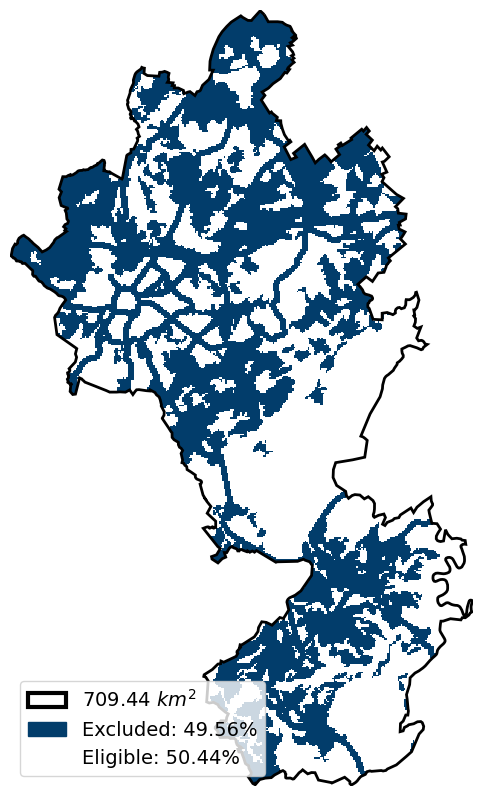

In [2]:
# Choose a region to operate on (Here, a predefined region for Aachen, Germany is used)
regionPath = gl._test_data_["aachenShapefile.shp"]

# Initialize ExclusionCalculator object
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

# Apply exclusions
ec.excludeRasterType(gl._test_data_["clc-aachen_clipped.tif"], value=(12,22))
# ec.excludeRasterType(gl._test_data_["clc-aachen_clipped.tif"], value=(1, 2), buffer=1000)
ec.excludeVectorType(gl._test_data_["aachenRoads.shp"], where="type='motorway' OR type='primary' OR type='trunk'", buffer=200)

# Draw result
ec.draw()

Copy the file from the land eligibility analysis to have a backup file.

In [3]:
# make a copy of the ec object so we can "reset" the ec object after distributing placements and have a "clean" ec again
ec_backup = copy(ec)

# 2. Distribute item placements within the eligible regions

### Basic Placement 
"Seperation" specifies the minimal distance between two objects.

<Axes: >

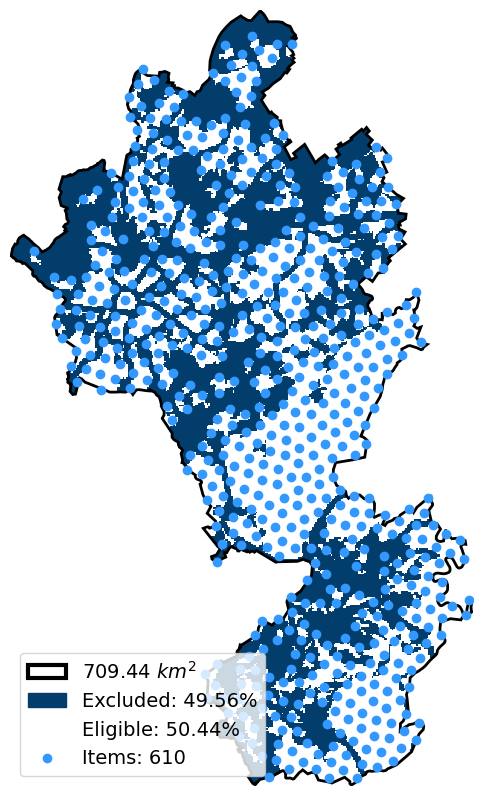

In [4]:
# Do placements
ec.distributeItems(separation=1000)

# Draw result
ec.draw()

### Spare the edges of a region  
Sometimes it is needed to spare the edges of a region so that the separation distances are maintained also between placements of neighbouring regions (avoidRegionBorders=True).

c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:1560: UserWarning: Memory efficient multiProcess failed, returning to safe linear processing.
  warn(


Memory useage during calc: 219.38671875 MB


<Axes: >

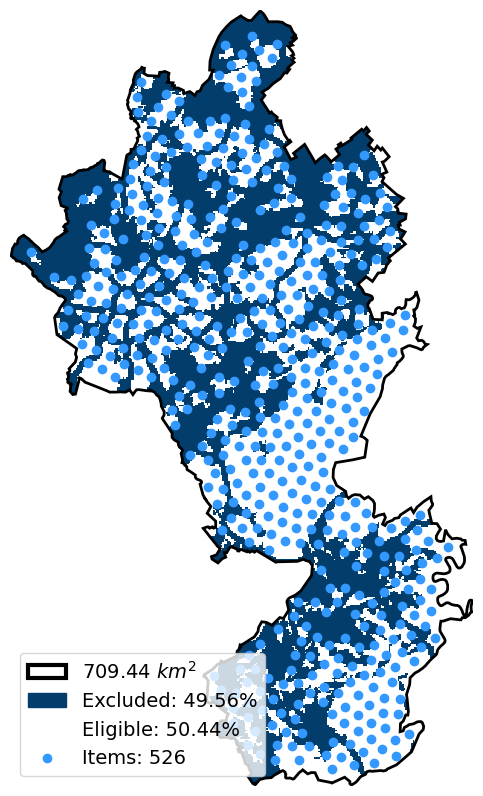

In [5]:
# reset the ec object to remove the "old" placements from above
ec = copy(ec_backup)
# repeat the step above and set the argument avoidRegionBorders to True
ec.distributeItems(separation=1000, avoidRegionBorders=True)

# Draw result. In comparison to above you can see that no placements are distributed towards the edges of the region, you can also see that less items were distributed
ec.draw()

### Direction-dependent placements  
If two different separation distances are defined, they represent the minimum required spacing between two objects along two perpendicular directions: an **axial** direction and a **transverse** direction.
The **axialDirection** parameter specifies the orientation of the axial axis in degrees, measured counter-clockwise relative to East.
When both axial and transverse distances are provided, the effective buffer distance applied at the boundary is the average of the two separation distances.

450


c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:1560: UserWarning: Memory efficient multiProcess failed, returning to safe linear processing.
  warn(


Memory useage during calc: 223.65234375 MB


<Axes: >

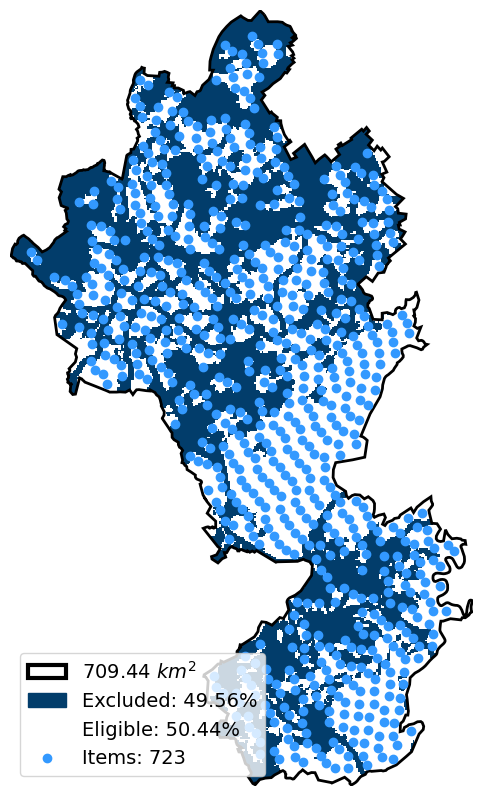

In [6]:
# reset the ec object again
ec = copy(ec_backup)
# do placements with "seperation=(axial, transverse), axialDirection"
ec.distributeItems(separation=(1200, 600), axialDirection=45, avoidRegionBorders=True)

# Draw result
ec.draw()

### Get the placements as XY coordinates

In [7]:
#print only the first 5 placements
print(ec.itemCoords[:5])

[[4053200.01 3098499.99]
 [4053550.   3098000.01]
 [4054800.01 3097999.99]
 [4051400.01 3097899.99]
 [4051850.   3097500.01]]


### Use wind direction data for placements

<Axes: >

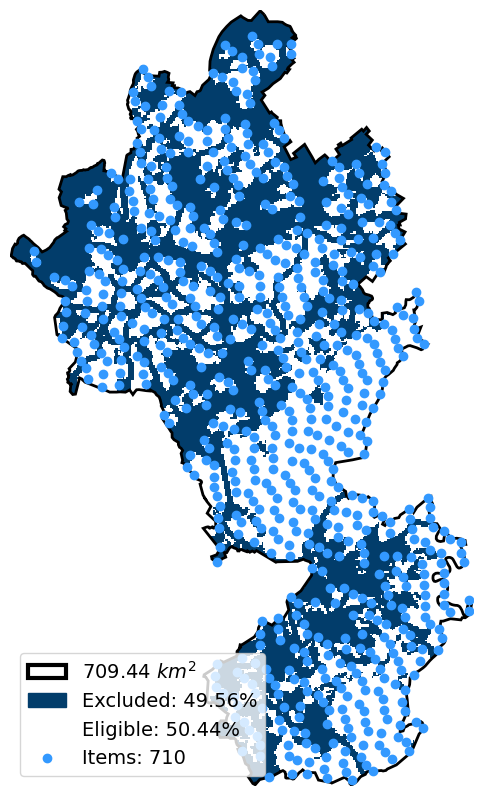

In [8]:
ec.distributeItems( 
    (1400, 600), 
    axialDirection=r"data/ERA5_wind_direction_100m_mean.tiff", 
    outputSRS=gk.srs.EPSG4326 )

ec.draw()

### Create a spatially varying raster and use it to apply location-dependent spacing when distributing items.

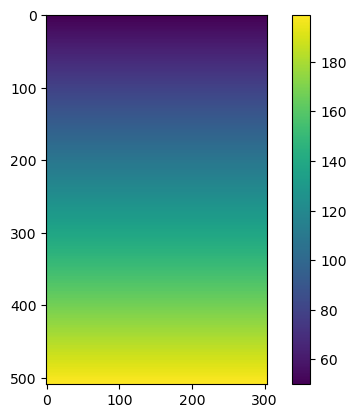

<Axes: >

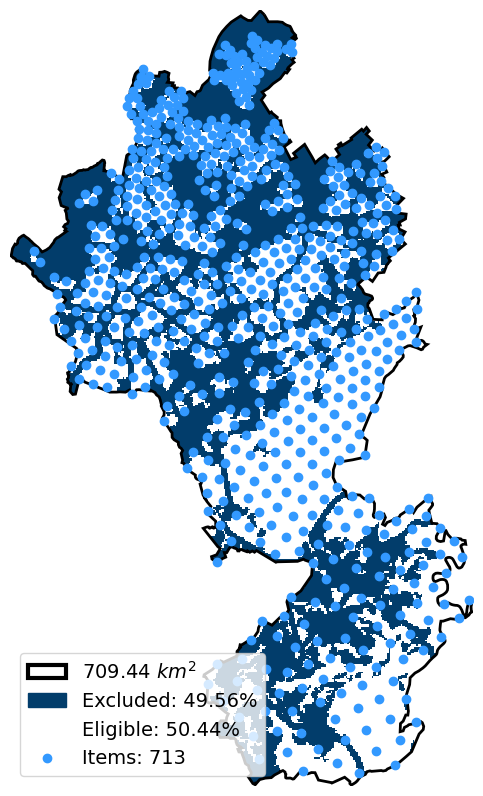

In [9]:
# Create a raster with values increasing from 50 to 200 from top to bottom
mat = np.zeros_like(ec.region.mask, dtype=np.uint8)
for i in range(mat.shape[0]):
    mat[i,:] = (200-50)*i/(mat.shape[0]) + 50
    
# Show the raster
h = plt.imshow(mat)
plt.colorbar(h)
plt.show()

# Convert the array into a raster used to scale separation distances
rotor_diam_raster = ec.region.createRaster(output="tmp/rotor_diameter.tif", data=mat)

# Place items using a variable spacing:
# effective spacing = 8.0 × local raster value
points = ec.distributeItems( 
    separation=8.0,
    sepScaling=rotor_diam_raster)

ec.draw()

### Individual placement areas

Additionally the hole area can be divided into one area for each placement and those can be saved as well.
'asArea=True' invokes the identification of nearby eligible areas using Voronoi ploygons.

PATH CHECK:
0 [4047638.73156244 3060649.99      ] <class 'numpy.ndarray'> False
1 [4050800.7011287  3056602.60419701] <class 'numpy.ndarray'> False
2 [4049899.91694316 3055847.10965804] <class 'numpy.ndarray'> False
3 [4043295.97089113 3055440.71297792] <class 'numpy.ndarray'> False
4 [4042997.425935 3056935.      ] <class 'numpy.ndarray'> False
5 [4043977.33675601 3061049.86984218] <class 'numpy.ndarray'> False
6 [4047638.73156244 3060649.99      ] <class 'numpy.ndarray'> False
PATH CHECK:
0 [4050750.01       3054331.26164475] <class 'numpy.ndarray'> False
1 [4049295.839982   3052149.99896415] <class 'numpy.ndarray'> False
2 [4048618.559319   3051569.47505106] <class 'numpy.ndarray'> False
3 [4045406.66666667 3052950.74211108] <class 'numpy.ndarray'> False
4 [4043340.23169184 3054883.04689319] <class 'numpy.ndarray'> False
5 [4043295.97089113 3055440.71297792] <class 'numpy.ndarray'> False
6 [4049899.91694316 3055847.10965804] <class 'numpy.ndarray'> False
7 [4050750.01       3055297.

<Axes: >

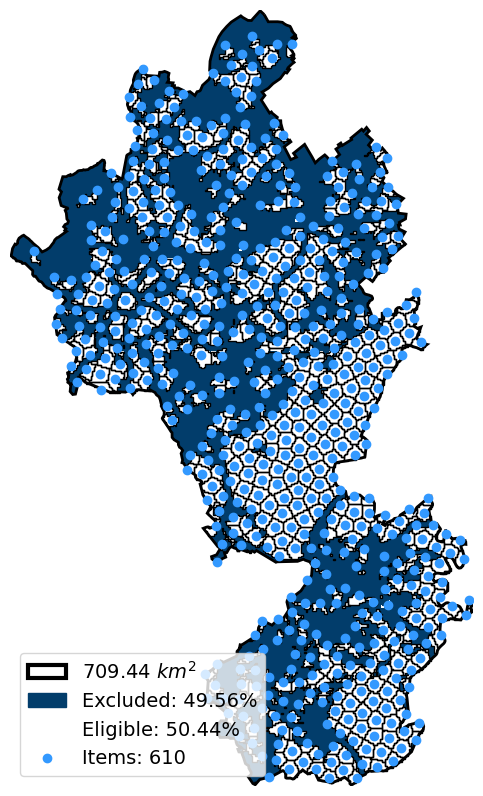

In [10]:
_old_polygon = gk.geom.polygon

# geokit expects polygon coordinates as Python tuples like (x, y),
# but ec.distributeItems(asArea=True) may pass NumPy arrays instead.
# This wrapper converts array/list coordinates to tuples before
# calling the original polygon function.
def polygon_fix(outerRing, srs=None, *args):
    outerRing = [tuple(p) if isinstance(p, (np.ndarray, list)) else p for p in outerRing]
    return _old_polygon(outerRing, srs=srs, *args)

# Replace geokit's polygon function with the patched version
gk.geom.polygon = polygon_fix

# Create placement areas (polygons around placed items) and save them as a shapefile
areas = ec.distributeItems(separation=1000, asArea=True, output="tmp/individual_placement_areas.shp")
# Create only the placement points and save them as a shapefile
points = ec.distributeItems(separation=1000, asArea=False, output="tmp/individual_placement_points.shp")

ec.draw()